## 1. Carga de los datos


In [ ]:
import pandas as pd

ruta = "/content/drive/MyDrive/Sesiones en vivo/Archivos - Sesiones en vivo/"

df_inspecciones = pd.read_excel(ruta + "inspecciones_calidad.xlsx")
df_responsables = pd.read_excel(ruta + "responsables_maestro.xlsx")
df_productos = pd.read_excel(ruta + "productos_maestro.xlsx")
df_costos = pd.read_excel(ruta + "costos_fallas.xlsx")

print("Inspecciones:", df_inspecciones.shape)
print("Responsables:", df_responsables.shape)
print("Productos:", df_productos.shape)
print("Costos:", df_costos.shape)

display(df_inspecciones.head())

Inspecciones: (180, 12)
Responsables: (15, 6)
Productos: (26, 7)
Costos: (32, 3)


,id_inspeccion,fecha_revision,id_producto,codigo_producto,lote,responsable_id,area,resultado_revision,tipo_falla,severidad,estado_caso,observacion
0,I0001,2026-01-17,P009,PRD-009,L2601-204,R011,LOGISTICA,Aprobado,NaN,NaN,Cerrado,Sin novedad
1,I0002,2026-03-15,P021,PRD-021,L2603-559,R010,Produccion,Rechazado,Rayado,Critica,Abierto,Producto con embalaje dañado
2,I0003,2026-01-14,P012,PRD-012,L2601-926,R001,LOGISTICA,Aprobado,NaN,NaN,NaN,Producto con embalaje dañado
3,I0004,2026-03-17,P003,PRD 003,L2603-396,R002,PRODUCCIÓN,Aprobado,NaN,NaN,Cerrado,Aplicar reinspección
4,I0005,2026-02-19,P022,PRD-022,L2602-763,R002,calidad,Aprobado,NaN,NaN,Cerrado,Pendiente validación supervisor


## 2. Diagnóstico inicial


In [ ]:
# =========================
# 1. DIAGNÓSTICO INICIAL
# =========================
def diagnostico_dataframe(df, nombre):
    print("=" * 70)
    print(f"DIAGNÓSTICO: {nombre}")
    print("=" * 70)

    print("\nDimensiones:")
    print(df.shape)

    print("\nTipos de datos:")
    display(df.dtypes.to_frame("tipo_dato"))

    print("\nValores nulos:")
    nulos = df.isna().sum().to_frame("nulos")
    nulos["porcentaje"] = (nulos["nulos"] / len(df) * 100).round(2)
    display(nulos.sort_values("nulos", ascending=False))

    print("\nDuplicados totales:")
    print(df.duplicated().sum())

    print("\nPrimeras filas:")
    display(df.head())

diagnostico_dataframe(df_inspecciones, "Inspecciones")
diagnostico_dataframe(df_responsables, "Responsables")
diagnostico_dataframe(df_productos, "Productos")
diagnostico_dataframe(df_costos, "Costos")

DIAGNÓSTICO: Inspecciones

Dimensiones:
(180, 12)

Tipos de datos:


,tipo_dato
id_inspeccion,object
fecha_revision,object
id_producto,object
codigo_producto,object
lote,object
responsable_id,object
area,object
resultado_revision,object
tipo_falla,object
severidad,object



Valores nulos:


,nulos,porcentaje
severidad,89,49.44
tipo_falla,86,47.78
estado_caso,33,18.33
id_inspeccion,0,0.00
codigo_producto,0,0.00
id_producto,0,0.00
fecha_revision,0,0.00
lote,0,0.00
resultado_revision,0,0.00
area,0,0.00



Duplicados totales:
0

Primeras filas:


...

,tipo_dato
tipo_falla,object
severidad,object
costo_estimado_usd,int64



Valores nulos:


,nulos,porcentaje
tipo_falla,0,0.0
severidad,0,0.0
costo_estimado_usd,0,0.0



Duplicados totales:
0

Primeras filas:


,tipo_falla,severidad,costo_estimado_usd
0,Golpe,Baja,12
1,Golpe,Media,28
2,Golpe,Alta,60
3,Golpe,Crítica,110
4,Rayado,Baja,8


In [ ]:
# =========================
# 2. REVISIÓN DE COLUMNAS CLAVE
# =========================

print("Valores únicos en 'area':")
display(pd.DataFrame(sorted(df_inspecciones["area"].astype(str).unique()), columns=["area"]))

print("Valores únicos en 'resultado_revision':")
display(pd.DataFrame(sorted(df_inspecciones["resultado_revision"].astype(str).unique()), columns=["resultado_revision"]))

print("Valores únicos en 'tipo_falla':")
display(pd.DataFrame(sorted(df_inspecciones["tipo_falla"].astype(str).unique()), columns=["tipo_falla"]))

print("Valores únicos en 'severidad':")
display(pd.DataFrame(sorted(df_inspecciones["severidad"].astype(str).unique()), columns=["severidad"]))

print("Valores únicos en 'estado_caso':")
display(pd.DataFrame(sorted(df_inspecciones["estado_caso"].astype(str).unique()), columns=["estado_caso"]))

Valores únicos en 'area':


,area
0,logística
1,producción
2,ALMACEN
3,Almacen
4,Almacén
5,CONTROL CALIDAD
6,Calidad
7,Ctrl Calidad
8,LOGISTICA
9,Logistica


Valores únicos en 'resultado_revision':


,resultado_revision
0,Aprobado
1,Observado
2,Rechazado


Valores únicos en 'tipo_falla':


,tipo_falla
0,GOLPE
1,Empaq. abierto
2,Empaque abierto
3,Etiqueta incorrecta
4,Etiquetado incorrecto
5,FUGA
6,Fuga
7,Golpe
8,Peso incorrecto
9,Peso incorreto


Valores únicos en 'severidad':


,severidad
0,ALTA
1,Alta
2,BAJA
3,Baja
4,CRÍTICA
5,Critica
6,Crítica
7,MEDIA
8,Media
9,alta


Valores únicos en 'estado_caso':


,estado_caso
0,ABIERTO
1,Abierto
2,Cerrado
3,En revisión
4,en revision
5,nan


In [ ]:
# =========================
# 3. DUPLICADOS POR CLAVES RELEVANTES
# =========================

print("Duplicados por id_inspeccion:")
print(df_inspecciones["id_inspeccion"].duplicated().sum())

print("\nDuplicados por responsable_id en responsables:")
print(df_responsables["responsable_id"].duplicated().sum())

print("\nDuplicados por id_producto en productos:")
print(df_productos["id_producto"].duplicated().sum())

print("\nDuplicados por combinación tipo_falla + severidad en costos:")
print(df_costos.duplicated(subset=["tipo_falla", "severidad"]).sum())

Duplicados por id_inspeccion:
0

Duplicados por responsable_id en responsables:
1

Duplicados por id_producto en productos:
1

Duplicados por combinación tipo_falla + severidad en costos:
0


## 3. Procesamiento de los datos

In [ ]:
# =========================
# 4. LIMPIEZA DE NOMBRES DE COLUMNAS
# =========================

def limpiar_columnas(df):
    df = df.copy()
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_")
    )
    return df

df_inspecciones = limpiar_columnas(df_inspecciones)
df_responsables = limpiar_columnas(df_responsables)
df_productos = limpiar_columnas(df_productos)
df_costos = limpiar_columnas(df_costos)

print(df_inspecciones.columns.tolist())
print(df_responsables.columns.tolist())
print(df_productos.columns.tolist())
print(df_costos.columns.tolist())

['id_inspeccion', 'fecha_revision', 'id_producto', 'codigo_producto', 'lote', 'responsable_id', 'area', 'resultado_revision', 'tipo_falla', 'severidad', 'estado_caso', 'observacion']
['responsable_id', 'nombre_responsable', 'cargo', 'supervisor', 'turno', 'estado']
['id_producto', 'codigo_producto', 'nombre_producto', 'categoria', 'subcategoria', 'planta', 'estado_producto']
['tipo_falla', 'severidad', 'costo_estimado_usd']


In [8]:
# =========================
# 5. LIMPIEZA DE TEXTOS
# =========================

def limpiar_texto_basico(valor):
    if pd.isna(valor):
        return valor
    valor = str(valor).strip()
    valor = " ".join(valor.split())
    return valor

columnas_texto_inspecciones = [
    "id_inspeccion", "id_producto", "codigo_producto", "lote", "responsable_id",
    "area", "resultado_revision", "tipo_falla", "severidad", "estado_caso", "observacion"
]

columnas_texto_responsables = [
    "responsable_id", "nombre_responsable", "cargo", "supervisor", "turno", "estado"
]

columnas_texto_productos = [
    "id_producto", "codigo_producto", "nombre_producto", "categoria", "subcategoria", "planta", "estado_producto"
]

columnas_texto_costos = [
    "tipo_falla", "severidad"
]

for col in columnas_texto_inspecciones:
    df_inspecciones[col] = df_inspecciones[col].apply(limpiar_texto_basico)

for col in columnas_texto_responsables:
    df_responsables[col] = df_responsables[col].apply(limpiar_texto_basico)

for col in columnas_texto_productos:
    df_productos[col] = df_productos[col].apply(limpiar_texto_basico)

for col in columnas_texto_costos:
    df_costos[col] = df_costos[col].apply(limpiar_texto_basico)

In [12]:
# =========================
# 6. NORMALIZACIÓN DE CATEGORÍAS
# =========================

import numpy as np

# ---------
# ÁREA
# ---------
mapa_area = {
    "LOGISTICA": "Logística",
    "Logistica": "Logística",
    "logistica": "Logística",
    "logística": "Logística",
    "Logística": "Logística",

    "PRODUCCION": "Producción",
    "Produccion": "Producción",
    "produccion": "Producción",
    "PRODUCCIÓN": "Producción",
    "Producción": "Producción",
    "producción": "Producción",

    "ALMACEN": "Almacén",
    "Almacen": "Almacén",
    "almacen": "Almacén",
    "Almacén": "Almacén",
    "almacén": "Almacén",

    "CALIDAD": "Calidad",
    "calidad": "Calidad",
    "Calidad": "Calidad",
    "CONTROL CALIDAD": "Calidad",
    "Ctrl Calidad": "Calidad"
}

# ---------
# RESULTADO
# ---------
mapa_resultado = {
    "Aprobado": "Aprobado",
    "Rechazado": "Rechazado"
}

# ---------
# ESTADO CASO
# ---------
mapa_estado_caso = {
    "ABIERTO": "Abierto",
    "Abierto": "Abierto",

    "Cerrado": "Cerrado",

    "En revisión": "En revisión",
    "en revision": "En revisión",
    "En revision": "En revisión"
}

# ---------
# SEVERIDAD
# ---------
mapa_severidad = {
    "ALTA": "Alta",
    "Alta": "Alta",
    "alta": "Alta",

    "MEDIA": "Media",
    "Media": "Media",
    "media": "Media",

    "BAJA": "Baja",
    "Baja": "Baja",
    "baja": "Baja",

    "CRÍTICA": "Crítica",
    "Critica": "Crítica",
    "Crítica": "Crítica"
}

# ---------
# TIPO FALLA
# ---------
mapa_tipo_falla = {
    "GOLPE": "Golpe",
    "Golpe": "Golpe",
    "golpe": "Golpe",

    "FUGA": "Fuga",
    "Fuga": "Fuga",
    "fuga": "Fuga",

    "Empaq. abierto": "Empaque abierto",
    "Empaque abierto": "Empaque abierto",
    "empaque abierto": "Empaque abierto",

    "Etiqueta incorrecta": "Etiquetado incorrecto",
    "Etiquetado incorrecto": "Etiquetado incorrecto",
    "etiquetado incorrecto": "Etiquetado incorrecto",

    "Peso incorrecto": "Peso incorrecto",
    "peso incorrecto": "Peso incorrecto",
    "Peso incorreto": "Peso incorrecto",

    "Rayado": "Rayado",
    "rayado": "Rayado",
    "Rayón": "Rayado",

    "Sellado defect": "Sellado defectuoso",
    "Sellado defectuoso": "Sellado defectuoso",
    "sellado defectuoso": "Sellado defectuoso",

    "vencimiento": "Vencimiento"
}

# Aplicar reemplazos
df_inspecciones["area"] = df_inspecciones["area"].replace(mapa_area)
df_inspecciones["resultado_revision"] = df_inspecciones["resultado_revision"].replace(mapa_resultado)
df_inspecciones["estado_caso"] = df_inspecciones["estado_caso"].replace(mapa_estado_caso)
df_inspecciones["severidad"] = df_inspecciones["severidad"].replace(mapa_severidad)
df_inspecciones["tipo_falla"] = df_inspecciones["tipo_falla"].replace(mapa_tipo_falla)

# Convertir strings "nan" en nulos reales
columnas_a_corregir = ["tipo_falla", "severidad", "estado_caso", "area"]
for col in columnas_a_corregir:
    df_inspecciones[col] = df_inspecciones[col].replace("nan", np.nan)

print("Áreas normalizadas:")
display(pd.DataFrame(sorted(df_inspecciones["area"].dropna().unique()), columns=["area"]))

print("Tipos de falla normalizados:")
display(pd.DataFrame(sorted(df_inspecciones["tipo_falla"].dropna().unique()), columns=["tipo_falla"]))

print("Severidades normalizadas:")
display(pd.DataFrame(sorted(df_inspecciones["severidad"].dropna().unique()), columns=["severidad"]))

print("Estados de caso normalizados:")
display(pd.DataFrame(sorted(df_inspecciones["estado_caso"].dropna().unique()), columns=["estado_caso"]))

Áreas normalizadas:


,area
0,Almacén
1,Calidad
2,Logística
3,Producción


Tipos de falla normalizados:


,tipo_falla
0,Empaque abierto
1,Etiquetado incorrecto
2,Fuga
3,Golpe
4,Peso incorrecto
5,Rayado
6,Sellado defectuoso
7,Vencimiento


Severidades normalizadas:


,severidad
0,Alta
1,Baja
2,Crítica
3,Media


Estados de caso normalizados:


,estado_caso
0,Abierto
1,Cerrado
2,En revisión


In [13]:
# =========================
# 7. NORMALIZACIÓN DE CÓDIGOS
# =========================

# código de producto
df_inspecciones["codigo_producto"] = (
    df_inspecciones["codigo_producto"]
    .str.replace(" ", "-", regex=False)
    .str.upper()
)

df_productos["codigo_producto"] = (
    df_productos["codigo_producto"]
    .str.replace(" ", "-", regex=False)
    .str.upper()
)

# ids
df_inspecciones["id_producto"] = df_inspecciones["id_producto"].str.upper()
df_productos["id_producto"] = df_productos["id_producto"].str.upper()

df_inspecciones["responsable_id"] = df_inspecciones["responsable_id"].str.upper()
df_responsables["responsable_id"] = df_responsables["responsable_id"].str.upper()

# normalización extra de ids por si traen espacios
df_inspecciones["id_producto"] = df_inspecciones["id_producto"].str.strip()
df_productos["id_producto"] = df_productos["id_producto"].str.strip()

df_inspecciones["responsable_id"] = df_inspecciones["responsable_id"].str.strip()
df_responsables["responsable_id"] = df_responsables["responsable_id"].str.strip()

print("Ejemplo códigos inspecciones:")
display(df_inspecciones[["id_producto", "codigo_producto", "responsable_id"]].head())

Ejemplo códigos inspecciones:


,id_producto,codigo_producto,responsable_id
0,P009,PRD-009,R011
1,P021,PRD-021,R010
2,P012,PRD-012,R001
3,P003,PRD-003,R002
4,P022,PRD-022,R002


In [14]:
# =========================
# 8. CONVERSIÓN DE FECHAS
# =========================

df_inspecciones["fecha_revision"] = pd.to_datetime(
    df_inspecciones["fecha_revision"],
    errors="coerce"
)

print("Cantidad de fechas nulas luego de conversión:")
print(df_inspecciones["fecha_revision"].isna().sum())

print("\nRango de fechas:")
print("Mínima:", df_inspecciones["fecha_revision"].min())
print("Máxima:", df_inspecciones["fecha_revision"].max())

Cantidad de fechas nulas luego de conversión:
66

Rango de fechas:
Mínima: 2026-01-03 00:00:00
Máxima: 2026-04-10 00:00:00


In [15]:
# =========================
# 9. ELIMINAR DUPLICADOS EN MAESTROS
# =========================

print("Responsables antes:", df_responsables.shape)
df_responsables = df_responsables.drop_duplicates(subset=["responsable_id"], keep="first")
print("Responsables después:", df_responsables.shape)

print("\nProductos antes:", df_productos.shape)
df_productos = df_productos.drop_duplicates(subset=["id_producto"], keep="first")
print("Productos después:", df_productos.shape)

print("\nCostos antes:", df_costos.shape)
df_costos = df_costos.drop_duplicates(subset=["tipo_falla", "severidad"], keep="first")
print("Costos después:", df_costos.shape)

Responsables antes: (15, 6)
Responsables después: (14, 6)

Productos antes: (26, 7)
Productos después: (25, 7)

Costos antes: (32, 3)
Costos después: (32, 3)


In [16]:
# =========================
# 10. VALIDACIONES INICIALES DE NEGOCIO
# =========================

# 1) Aprobado con tipo_falla informado
val_1 = df_inspecciones[
    (df_inspecciones["resultado_revision"] == "Aprobado") &
    (df_inspecciones["tipo_falla"].notna())
]

print("1) Aprobado con tipo_falla informado:", len(val_1))
display(val_1.head())

# 2) Rechazado sin tipo_falla
val_2 = df_inspecciones[
    (df_inspecciones["resultado_revision"] == "Rechazado") &
    (df_inspecciones["tipo_falla"].isna())
]

print("2) Rechazado sin tipo_falla:", len(val_2))
display(val_2.head())

# 3) Rechazado sin severidad
val_3 = df_inspecciones[
    (df_inspecciones["resultado_revision"] == "Rechazado") &
    (df_inspecciones["severidad"].isna())
]

print("3) Rechazado sin severidad:", len(val_3))
display(val_3.head())

# 4) Fecha futura
val_4 = df_inspecciones[
    df_inspecciones["fecha_revision"] > pd.Timestamp.today()
]

print("4) Fechas futuras:", len(val_4))
display(val_4.head())

# 5) Estado de caso vacío
val_5 = df_inspecciones[
    df_inspecciones["estado_caso"].isna()
]

print("5) Estado de caso vacío:", len(val_5))
display(val_5.head())

1) Aprobado con tipo_falla informado: 10


,id_inspeccion,fecha_revision,id_producto,codigo_producto,lote,responsable_id,area,resultado_revision,tipo_falla,severidad,estado_caso,observacion
11,I0012,NaT,P023,PRD-023,L2603-787,R011,Producción,Aprobado,Golpe,Baja,Abierto,Revisar lote por diferencias
17,I0018,NaT,P002,PRD-002,L2603-698,R008,Producción,Aprobado,Golpe,Baja,Abierto,Se detecta diferencia visual
39,I0040,NaT,P021,PRD-021,L2601-353,R004,Producción,Aprobado,Golpe,Media,Abierto,Aplicar reinspección
64,I0065,2026-01-14,P004,PRD-004,L2601-202,R008,Calidad,Aprobado,Rayado,Media,Abierto,Registro manual del turno
79,I0080,2026-01-19,P021,PRD-021,L2601-490,R010,Logística,Aprobado,Etiquetado incorrecto,Baja,Cerrado,Aplicar reinspección


2) Rechazado sin tipo_falla: 0


,id_inspeccion,fecha_revision,id_producto,codigo_producto,lote,responsable_id,area,resultado_revision,tipo_falla,severidad,estado_caso,observacion


3) Rechazado sin severidad: 0


,id_inspeccion,fecha_revision,id_producto,codigo_producto,lote,responsable_id,area,resultado_revision,tipo_falla,severidad,estado_caso,observacion


4) Fechas futuras: 1


,id_inspeccion,fecha_revision,id_producto,codigo_producto,lote,responsable_id,area,resultado_revision,tipo_falla,severidad,estado_caso,observacion
87,I0088,2026-04-10,P004,PRD-004,L2602-279,R003,Producción,Aprobado,NaN,NaN,NaN,Registro manual del turno


5) Estado de caso vacío: 33


,id_inspeccion,fecha_revision,id_producto,codigo_producto,lote,responsable_id,area,resultado_revision,tipo_falla,severidad,estado_caso,observacion
2,I0003,2026-01-14,P012,PRD-012,L2601-926,R001,Logística,Aprobado,NaN,NaN,NaN,Producto con embalaje dañado
5,I0006,NaT,P025,PRD-025,L2602-924,R006,Calidad,Aprobado,NaN,NaN,NaN,Pendiente validación supervisor
24,I0025,NaT,P006,PRD-006,L2602-854,R006,Calidad,Aprobado,NaN,NaN,NaN,Registro manual del turno
25,I0026,NaT,P008,PRD-008,L2601-458,R005,Producción,Aprobado,NaN,NaN,NaN,Revisar lote por diferencias
35,I0036,2026-02-25,P025,PRD-025,L2602-977,R013,Logística,Aprobado,NaN,NaN,NaN,Pendiente validación supervisor


In [17]:
# =========================
# 11. VALIDACIÓN DE MATCHES
# =========================

# responsables no encontrados
responsables_no_match = df_inspecciones[
    ~df_inspecciones["responsable_id"].isin(df_responsables["responsable_id"])
]

print("Responsables no encontrados en maestro:", len(responsables_no_match))
display(responsables_no_match[["id_inspeccion", "responsable_id"]].head())

# productos no encontrados
productos_no_match = df_inspecciones[
    ~df_inspecciones["id_producto"].isin(df_productos["id_producto"])
]

print("Productos no encontrados en maestro:", len(productos_no_match))
display(productos_no_match[["id_inspeccion", "id_producto", "codigo_producto"]].head())

Responsables no encontrados en maestro: 3


,id_inspeccion,responsable_id
10,I0011,R015
57,I0058,R015
102,I0103,R015


Productos no encontrados en maestro: 3


,id_inspeccion,id_producto,codigo_producto
23,I0024,P027,PRD-027
76,I0077,P026,PRD-026
138,I0139,P027,PRD-027


In [18]:
# =========================
# 12. CRUCE DE TABLAS
# =========================

df_base = df_inspecciones.merge(
    df_responsables,
    on="responsable_id",
    how="left",
    suffixes=("", "_resp")
)

df_base = df_base.merge(
    df_productos,
    on=["id_producto", "codigo_producto"],
    how="left",
    suffixes=("", "_prod")
)

print("Dimensión base consolidada:", df_base.shape)
display(df_base.head())

Dimensión base consolidada: (180, 22)


,id_inspeccion,fecha_revision,id_producto,codigo_producto,lote,responsable_id,area,resultado_revision,tipo_falla,severidad,...,nombre_responsable,cargo,supervisor,turno,estado,nombre_producto,categoria,subcategoria,planta,estado_producto
0,I0001,2026-01-17,P009,PRD-009,L2601-204,R011,Logística,Aprobado,NaN,NaN,...,Karen Vidal,Analista de Calidad,Laura Pérez,Tarde,Activo,Desinfectante 900ml,Limpieza,Desinfectante,Planta Centro,Activo
1,I0002,2026-03-15,P021,PRD-021,L2603-559,R010,Producción,Rechazado,Rayado,Crítica,...,Jorge Núñez,Encargado Almacén,Andrés Ruiz,Mañana,Activo,Lavaloza 750ml,Limpieza,Lavaloza,Planta Centro,Activo
2,I0003,2026-01-14,P012,PRD-012,L2601-926,R001,Logística,Aprobado,NaN,NaN,...,Ana Torres,Analista de Calidad,Laura Pérez,Mañana,Activo,Crema Corporal 250ml,Cuidado Personal,Piel,Planta Centro,Activo
3,I0004,2026-03-17,P003,PRD-003,L2603-396,R002,Producción,Aprobado,NaN,NaN,...,Bruno Díaz,Inspector de Calidad,Laura Pérez,Tarde,Activo,Queso Fresco 500g,Lácteos,Queso,Planta Norte,Activo
4,I0005,2026-02-19,P022,PRD-022,L2602-763,R002,Calidad,Aprobado,NaN,NaN,...,Bruno Díaz,Inspector de Calidad,Laura Pérez,Tarde,Activo,Toallas Húmedas 80u,Cuidado Personal,Higiene,Planta Centro,Activo


In [19]:
# =========================
# 13. CRUCE CON COSTOS
# =========================

df_base = df_base.merge(
    df_costos,
    on=["tipo_falla", "severidad"],
    how="left"
)

print("Dimensión base consolidada con costos:", df_base.shape)
display(df_base.head())

Dimensión base consolidada con costos: (180, 23)


,id_inspeccion,fecha_revision,id_producto,codigo_producto,lote,responsable_id,area,resultado_revision,tipo_falla,severidad,...,cargo,supervisor,turno,estado,nombre_producto,categoria,subcategoria,planta,estado_producto,costo_estimado_usd
0,I0001,2026-01-17,P009,PRD-009,L2601-204,R011,Logística,Aprobado,NaN,NaN,...,Analista de Calidad,Laura Pérez,Tarde,Activo,Desinfectante 900ml,Limpieza,Desinfectante,Planta Centro,Activo,NaN
1,I0002,2026-03-15,P021,PRD-021,L2603-559,R010,Producción,Rechazado,Rayado,Crítica,...,Encargado Almacén,Andrés Ruiz,Mañana,Activo,Lavaloza 750ml,Limpieza,Lavaloza,Planta Centro,Activo,85.0
2,I0003,2026-01-14,P012,PRD-012,L2601-926,R001,Logística,Aprobado,NaN,NaN,...,Analista de Calidad,Laura Pérez,Mañana,Activo,Crema Corporal 250ml,Cuidado Personal,Piel,Planta Centro,Activo,NaN
3,I0004,2026-03-17,P003,PRD-003,L2603-396,R002,Producción,Aprobado,NaN,NaN,...,Inspector de Calidad,Laura Pérez,Tarde,Activo,Queso Fresco 500g,Lácteos,Queso,Planta Norte,Activo,NaN
4,I0005,2026-02-19,P022,PRD-022,L2602-763,R002,Calidad,Aprobado,NaN,NaN,...,Inspector de Calidad,Laura Pérez,Tarde,Activo,Toallas Húmedas 80u,Cuidado Personal,Higiene,Planta Centro,Activo,NaN


In [20]:
# =========================
# 14. BANDERAS DE REVISIÓN
# =========================

df_base["flag_responsable_no_encontrado"] = df_base["nombre_responsable"].isna()
df_base["flag_producto_no_encontrado"] = df_base["nombre_producto"].isna()

df_base["flag_aprobado_con_falla"] = (
    (df_base["resultado_revision"] == "Aprobado") &
    (df_base["tipo_falla"].notna())
)

df_base["flag_rechazado_sin_falla"] = (
    (df_base["resultado_revision"] == "Rechazado") &
    (df_base["tipo_falla"].isna())
)

df_base["flag_rechazado_sin_severidad"] = (
    (df_base["resultado_revision"] == "Rechazado") &
    (df_base["severidad"].isna())
)

df_base["flag_estado_caso_vacio"] = df_base["estado_caso"].isna()

display(df_base[[
    "id_inspeccion", "responsable_id", "id_producto", "resultado_revision",
    "tipo_falla", "severidad",
    "flag_responsable_no_encontrado",
    "flag_producto_no_encontrado",
    "flag_aprobado_con_falla",
    "flag_rechazado_sin_falla"
]].head())

,id_inspeccion,responsable_id,id_producto,resultado_revision,tipo_falla,severidad,flag_responsable_no_encontrado,flag_producto_no_encontrado,flag_aprobado_con_falla,flag_rechazado_sin_falla
0,I0001,R011,P009,Aprobado,NaN,NaN,False,False,False,False
1,I0002,R010,P021,Rechazado,Rayado,Crítica,False,False,False,False
2,I0003,R001,P012,Aprobado,NaN,NaN,False,False,False,False
3,I0004,R002,P003,Aprobado,NaN,NaN,False,False,False,False
4,I0005,R002,P022,Aprobado,NaN,NaN,False,False,False,False


In [21]:
# =========================
# 15. BASE DE REGISTROS OBSERVADOS
# =========================

df_observados = df_base[
    (df_base["flag_responsable_no_encontrado"]) |
    (df_base["flag_producto_no_encontrado"]) |
    (df_base["flag_aprobado_con_falla"]) |
    (df_base["flag_rechazado_sin_falla"]) |
    (df_base["flag_rechazado_sin_severidad"]) |
    (df_base["flag_estado_caso_vacio"])
].copy()

print("Cantidad de registros observados:", len(df_observados))
display(df_observados.head())

Cantidad de registros observados: 47


,id_inspeccion,fecha_revision,id_producto,codigo_producto,lote,responsable_id,area,resultado_revision,tipo_falla,severidad,...,subcategoria,planta,estado_producto,costo_estimado_usd,flag_responsable_no_encontrado,flag_producto_no_encontrado,flag_aprobado_con_falla,flag_rechazado_sin_falla,flag_rechazado_sin_severidad,flag_estado_caso_vacio
2,I0003,2026-01-14,P012,PRD-012,L2601-926,R001,Logística,Aprobado,NaN,NaN,...,Piel,Planta Centro,Activo,NaN,False,False,False,False,False,True
5,I0006,NaT,P025,PRD-025,L2602-924,R006,Calidad,Aprobado,NaN,NaN,...,Gaseosas,Planta Este,Activo,NaN,False,False,False,False,False,True
10,I0011,NaT,P003,PRD-003,L2601-228,R015,Logística,Aprobado,NaN,NaN,...,Queso,Planta Norte,Activo,NaN,True,False,False,False,False,False
11,I0012,NaT,P023,PRD-023,L2603-787,R011,Producción,Aprobado,Golpe,Baja,...,Cereal,Planta Sur,Activo,12.0,False,False,True,False,False,False
17,I0018,NaT,P002,PRD-002,L2603-698,R008,Producción,Aprobado,Golpe,Baja,...,Leche,Planta Norte,Activo,12.0,False,False,True,False,False,False


## 4. Levantamiento de información

In [24]:
# =========================
# 16. MÉTRICAS PRINCIPALES
# =========================

# indicador de falla
df_base["tiene_falla"] = np.where(df_base["resultado_revision"] == "Rechazado", 1, 0)

# costo solo si hay falla
df_base["costo_estimado_usd"] = df_base["costo_estimado_usd"].fillna(0)

resumen_responsable = (
    df_base
    .groupby("nombre_responsable", dropna=False)
    .agg(
        total_revisados=("id_inspeccion", "count"),
        total_con_falla=("tiene_falla", "sum"),
        costo_total_estimado=("costo_estimado_usd", "sum")
    )
    .reset_index()
)

resumen_responsable["tasa_falla"] = (
    resumen_responsable["total_con_falla"] / resumen_responsable["total_revisados"]
).round(4)

resumen_responsable = resumen_responsable.sort_values(
    by=["total_con_falla", "costo_total_estimado"],
    ascending=False
)

display(resumen_responsable.head(10))

,nombre_responsable,total_revisados,total_con_falla,costo_total_estimado,tasa_falla
13,Nicolás Ibarra,15,7,564.0,0.4667
9,Jorge Núñez,19,6,570.0,0.3158
11,Luis Peña,15,6,384.0,0.4000
3,Diego León,13,4,308.0,0.3077
6,Gabriela Ríos,9,4,207.0,0.4444
10,Karen Vidal,17,3,362.0,0.1765
5,Felipe Cruz,14,3,327.0,0.2143
7,Héctor Silva,11,3,289.0,0.2727
12,María Cano,13,3,152.0,0.2308
8,Inés Pardo,7,3,130.0,0.4286


In [26]:
# =========================
# 17. MÉTRICAS POR ÁREA
# =========================

resumen_area = (
    df_base
    .groupby("area", dropna=False)
    .agg(
        total_revisados=("id_inspeccion", "count"),
        total_con_falla=("tiene_falla", "sum"),
        costo_total_estimado=("costo_estimado_usd", "sum")
    )
    .reset_index()
)

resumen_area["tasa_falla"] = (
    resumen_area["total_con_falla"] / resumen_area["total_revisados"]
).round(4)

resumen_area = resumen_area.sort_values(by="total_con_falla", ascending=False)

display(resumen_area)

,area,total_revisados,total_con_falla,costo_total_estimado,tasa_falla
1,Calidad,86,25,2271.0,0.2907
3,Producción,45,14,1036.0,0.3111
0,Almacén,17,5,217.0,0.2941
2,Logística,32,5,515.0,0.1562


In [27]:
# =========================
# 18. MÉTRICAS POR TIPO DE FALLA
# =========================

resumen_falla = (
    df_base[df_base["tipo_falla"].notna()]
    .groupby("tipo_falla")
    .agg(
        cantidad=("id_inspeccion", "count"),
        costo_total_estimado=("costo_estimado_usd", "sum")
    )
    .reset_index()
    .sort_values(by="cantidad", ascending=False)
)

display(resumen_falla)

,tipo_falla,cantidad,costo_total_estimado
1,Etiquetado incorrecto,21,650.0
3,Golpe,18,456.0
6,Sellado defectuoso,15,928.0
0,Empaque abierto,12,705.0
5,Rayado,10,245.0
2,Fuga,8,506.0
4,Peso incorrecto,8,309.0
7,Vencimiento,2,240.0


In [28]:
# =========================
# 19. TOP RESPONSABLES CON MÁS FALLAS
# =========================

top_responsables = (
    resumen_responsable
    .sort_values(by="total_con_falla", ascending=False)
    .head(10)
)

display(top_responsables)

,nombre_responsable,total_revisados,total_con_falla,costo_total_estimado,tasa_falla
13,Nicolás Ibarra,15,7,564.0,0.4667
9,Jorge Núñez,19,6,570.0,0.3158
11,Luis Peña,15,6,384.0,0.4000
3,Diego León,13,4,308.0,0.3077
6,Gabriela Ríos,9,4,207.0,0.4444
10,Karen Vidal,17,3,362.0,0.1765
5,Felipe Cruz,14,3,327.0,0.2143
7,Héctor Silva,11,3,289.0,0.2727
12,María Cano,13,3,152.0,0.2308
8,Inés Pardo,7,3,130.0,0.4286


In [29]:
# =========================
# 20. RESUMEN DE OBSERVACIONES
# =========================

resumen_observaciones = pd.DataFrame({
    "tipo_observacion": [
        "Responsable no encontrado",
        "Producto no encontrado",
        "Aprobado con falla",
        "Rechazado sin falla",
        "Rechazado sin severidad",
        "Estado de caso vacío"
    ],
    "cantidad": [
        df_base["flag_responsable_no_encontrado"].sum(),
        df_base["flag_producto_no_encontrado"].sum(),
        df_base["flag_aprobado_con_falla"].sum(),
        df_base["flag_rechazado_sin_falla"].sum(),
        df_base["flag_rechazado_sin_severidad"].sum(),
        df_base["flag_estado_caso_vacio"].sum()
    ]
})

display(resumen_observaciones)

,tipo_observacion,cantidad
0,Responsable no encontrado,3
1,Producto no encontrado,3
2,Aprobado con falla,10
3,Rechazado sin falla,0
4,Rechazado sin severidad,0
5,Estado de caso vacío,33


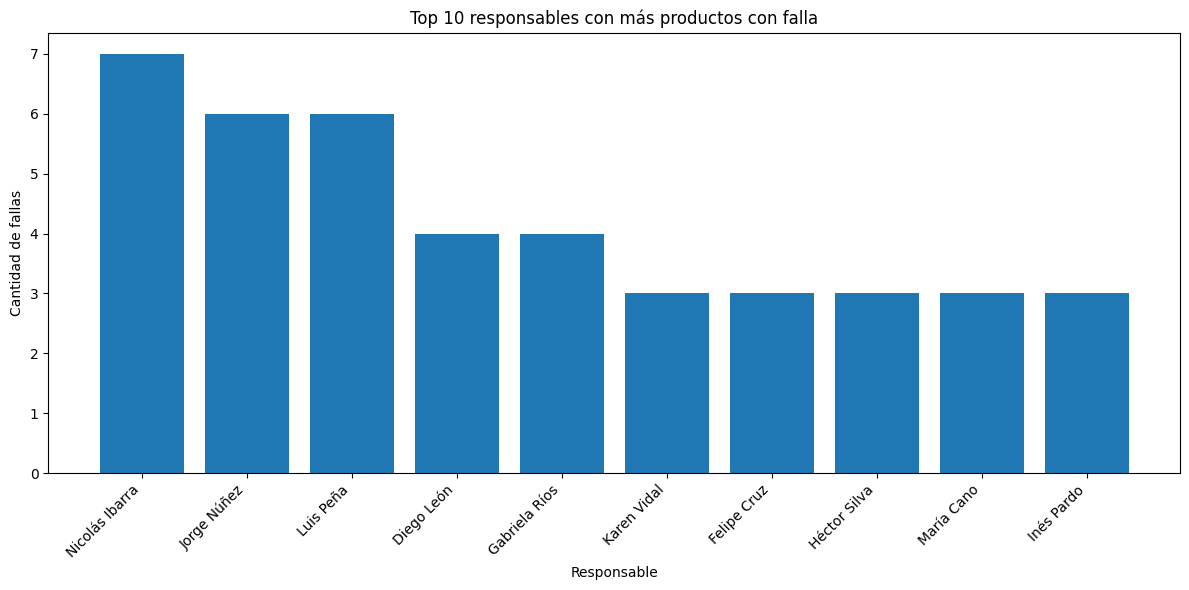

In [30]:
# =========================
# 21. GRÁFICO - FALLAS POR RESPONSABLE
# =========================

import matplotlib.pyplot as plt

graf_1 = (
    resumen_responsable
    .dropna(subset=["nombre_responsable"])
    .sort_values(by="total_con_falla", ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))
plt.bar(graf_1["nombre_responsable"], graf_1["total_con_falla"])
plt.xticks(rotation=45, ha="right")
plt.title("Top 10 responsables con más productos con falla")
plt.xlabel("Responsable")
plt.ylabel("Cantidad de fallas")
plt.tight_layout()
plt.show()

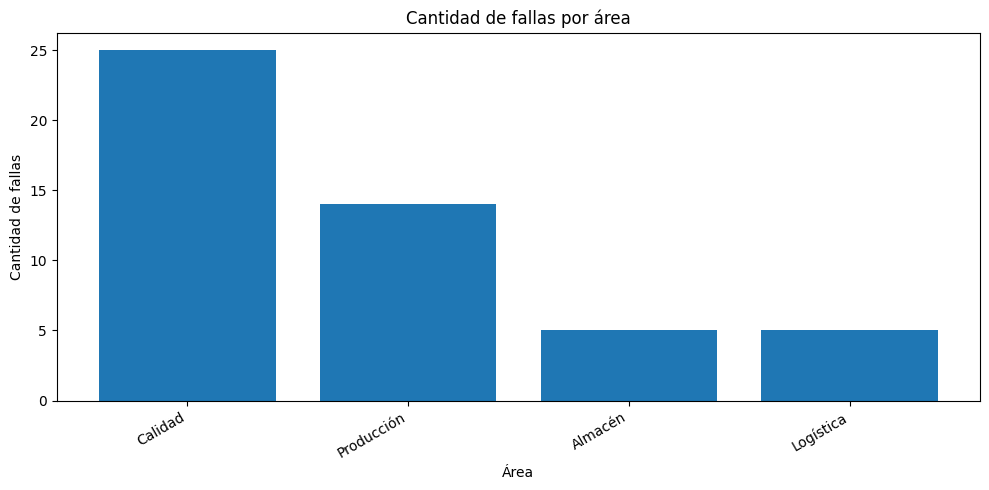

In [31]:
# =========================
# 22. GRÁFICO - FALLAS POR ÁREA
# =========================

graf_2 = resumen_area.sort_values(by="total_con_falla", ascending=False)

plt.figure(figsize=(10,5))
plt.bar(graf_2["area"], graf_2["total_con_falla"])
plt.xticks(rotation=30, ha="right")
plt.title("Cantidad de fallas por área")
plt.xlabel("Área")
plt.ylabel("Cantidad de fallas")
plt.tight_layout()
plt.show()

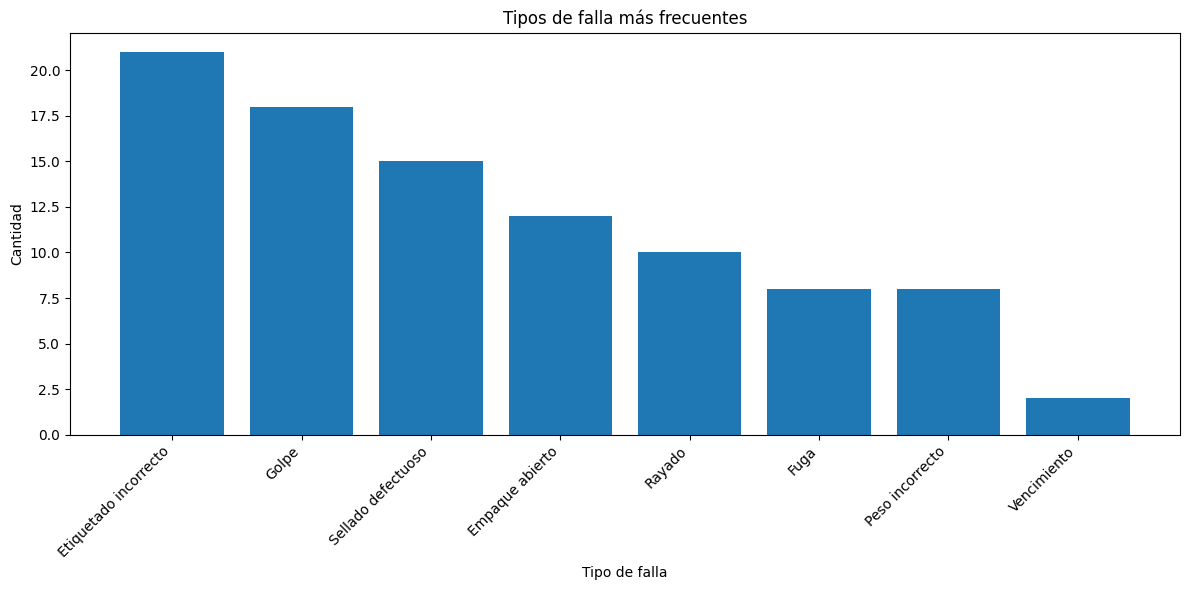

In [32]:
# =========================
# 23. GRÁFICO - TIPO DE FALLA
# =========================

graf_3 = resumen_falla.head(10)

plt.figure(figsize=(12,6))
plt.bar(graf_3["tipo_falla"], graf_3["cantidad"])
plt.xticks(rotation=45, ha="right")
plt.title("Tipos de falla más frecuentes")
plt.xlabel("Tipo de falla")
plt.ylabel("Cantidad")
plt.tight_layout()
plt.show()